# Retinal layer segmentation in OCT with the pretrained nnU-Net (OCT-SAM paper)

**Paper:** "Deep learning for interactive and automated inner retinal layer segmentation in OCT of patients with retinitis pigmentosa using limited training data" — medRxiv preprint v1, DOI [10.64898/2026.06.16.26355668](https://doi.org/10.64898/2026.06.16.26355668)

**Author code:** [`computational-cell-analytics/oct-sam`](https://github.com/computational-cell-analytics/oct-sam) @ commit `012aa0c99cf6d578bb23e94743c13f15f856e7d4`

**This notebook (minimal executed demonstration):**
1. Downloads the paper's released pretrained **nnU-Net** model (`nnunet_model_001_oct-2d.zip`, 329.3 MB, author ownCloud) and installs it exactly as documented in `doc/nnunet.md`.
2. Downloads **one annotated OCT B-scan** from the public Duke DME dataset (Chiu et al., BOE 2015) — one of the two public datasets the paper used — including its human `manual1` layer annotation.
3. Runs the author-documented inference `nnUNetv2_predict -d 001 -c 2d -f 0` to segment the **7 retinal layers** (RNFL, GCIPL, INL, OPL, ONL, EZ, RPE).
4. Computes per-layer thickness profiles and the total-retina span with the author's metric (column pixel count × axial pixel spacing, `oct_tools/metric_utils.py`) and compares them with the human annotation.

**Important limitations** (see the end for details):
- The paper's own RP test data (UMG-RP) is **not published**; RP-specific results cannot be reproduced. This demonstration runs the released model on a **held-in public training-dataset sample** — it is a pipeline and sanity demonstration, **not** a performance verification of the paper's reported scores.
- The paper's preferred interactive model OCT-SAM (µSAM/napari GUI) is out of scope; the released nnU-Net is the paper's preferred automated model.

**実行内容（日本語）:** 公開済みの学習済み nnU-Net モデルと Duke DME 公開データセットのBスキャン1枚を用い、著者のドキュメントどおりに7層の網膜層セグメンテーションと層厚計測を実行・比較します。論文のRP固有の評価はデータが非公開のため対象外です。

## 1. Runtime selection

**No GPU is needed.** The author documentation demonstrates CPU inference (`nnUNetv2_predict ... -device cpu`, `doc/nnunet.md`), and this minimal example is a single 2D B-scan, so a standard **CPU runtime** is sufficient (select "Runtime → Change runtime type → CPU", or any runtime; the inference device is auto-detected below). Expected total time ≈ 10–20 min, dominated by downloads (model 329.3 MB + Duke dataset zip) and `pip install nnunetv2`.

**ランタイムについて（日本語）:** Bスキャン1枚のCPU推論は高速なため、GPUは不要です。ランタイムはCPUで構いません。

Check the environment first. The notebook records the Python and PyTorch versions and whether a CUDA GPU is present; the inference device is chosen from this check (GPU is used only if present, otherwise CPU, which is fully supported by the author documentation).

In [ ]:
import os, sys, platform, subprocess
print("Python:", sys.version.split()[0], "| platform:", platform.platform())

import torch
print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Inference device that will be used:", DEVICE)

Python: 3.13.16 | platform: Linux-6.6.122+-x86_64-with-glibc2.39


torch: 2.11.0+cpu | CUDA available: False
Inference device that will be used: cpu


## 2. Setup

Install the paper's required inference dependency `nnunetv2` (nnU-Net v2, [MIC-DKFZ](https://github.com/MIC-DKFZ/nnUNet)) via pip, following `doc/nnunet.md`. This reuses the preinstalled PyTorch and takes a few minutes. `nibabel`, `imageio`, `scipy` and `matplotlib` (used below) are already available in Colab or installed here.
**日本語:** 論文のドキュメントに従い `pip` で `nnunetv2` をインストールします。

In [ ]:
%pip install -q nnunetv2
import nnunetv2, importlib.metadata
print("nnunetv2:", nnunetv2.__version__ if hasattr(nnunetv2, "__version__") else importlib.metadata.version("nnunetv2"))

  Installing build dependencies ... done


  Getting requirements to build wheel ... done


  Preparing metadata (pyproject.toml) ... done


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 7.1 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.1/291.1 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/52.8 MB 203.0 MB/s eta 0:00:01

...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 52.8/52.8 MB 106.0 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━ 22.0/28.1 MB 113.0 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/4.9 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 10.8 MB/s eta 0:00:00


nnunetv2: 2.8.1


## 3. Download the released pretrained nnU-Net model

**Provenance:** the author repository README ("Segmentation models") links the pretrained nnU-Net model at
`https://owncloud.gwdg.de/index.php/s/ffZ4MvFWt8E5jpv` (share-page metadata: `nnunet_model_001_oct-2d.zip`, 329.3 MB).
We download it from that exact share's direct-download URL into `/content` (Colab VM) and verify the byte size against the share-page value.
**日本語:** 著者リポジトリのREADMEが示すownCloud共有から学習済みモデルをダウンロードし、サイズを検証します。

In [ ]:
import urllib.request, pathlib

MODEL_URL = "https://owncloud.gwdg.de/index.php/s/ffZ4MvFWt8E5jpv/download"
MODEL_PATH = "/content/nnunet_model_001_oct-2d.zip"
EXPECTED_SIZE_MB = 329.3  # share-page metadata, verified 2026-10-07

if not pathlib.Path(MODEL_PATH).exists():
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)

size = pathlib.Path(MODEL_PATH).stat().st_size
print(f"Downloaded {MODEL_PATH}: {size:,} bytes = {size / 1024**2:.1f} MB (share page: {EXPECTED_SIZE_MB} MB)")
assert abs(size / 1024**2 - EXPECTED_SIZE_MB) < 5.0, "Unexpected model size" 

Downloaded /content/nnunet_model_001_oct-2d.zip: 345,307,337 bytes = 329.3 MB (share page: 329.3 MB)


Install the model into the nnU-Net results directory exactly as the author documentation instructs (`nnUNetv2_install_pretrained_model_from_zip`), then print the installed model's `dataset.json`. This confirms the model identity and its label scheme (background + retinal layer IDs 1–7) before inference.
**日本語:** 著者ドキュメントどおり `nnUNetv2_install_pretrained_model_from_zip` でモデルをインストールし、`dataset.json` でラベル構成を確認します。

In [ ]:
import glob, json, os

os.environ["nnUNet_results"] = "/content/nnUNet_results"
if not glob.glob("/content/nnUNet_results/Dataset001*"):
    subprocess.run(
        ["nnUNetv2_install_pretrained_model_from_zip", MODEL_PATH],
        check=True, env=os.environ,
    )

print("Installed:", glob.glob("/content/nnUNet_results/Dataset001*"))
dataset_json_path = glob.glob("/content/nnUNet_results/Dataset001*/**/dataset.json", recursive=True)[0]
with open(dataset_json_path) as f:
    dj = json.load(f)
print(json.dumps(dj, indent=2))

Installed: ['/content/nnUNet_results/Dataset001_OCT-2d']
{
  "channel_names": {
    "0": "intensity"
  },
  "labels": {
    "background": 0,
    "RNFL": 1,
    "GCLIPL": 2,
    "INL": 3,
    "OPL": 4,
    "ONL": 5,
    "EZ": 6,
    "RPE": 7
  },
  "numTraining": 1902,
  "file_ending": ".nii.gz"
}


## 4. Download the public Duke DME sample (with its human annotation)

**Provenance:** the author repository's `doc/nnunet.md` and `doc/training_data.md` use the public **Duke DME** dataset (Chiu et al., Biomedical Optics Express 2015), linked from the author's data-preparation script as `https://people.duke.edu/~sf59/Chiu_BOE_2014_dataset.htm`, with the direct archive at `http://www.duke.edu/~sf59/Datasets/2015_BOE_Chiu2.zip` and voxel size **3.87 µm (axial) × 11.33 µm (lateral)**. We download the archive into `/content`, list its contents, and extract **only one `.mat` volume** (the first in sorted order) to keep processing minimal. The exact archive size is printed on download.
**日本語:** 論文が使用した公開データセット Duke DME のアーカイブをダウンロードし、最初の1ボリューム（.mat）のみ展開します。

In [ ]:
import urllib.request, zipfile

DUKE_URL = "http://www.duke.edu/~sf59/Datasets/2015_BOE_Chiu2.zip"
DUKE_ZIP = "/content/2015_BOE_Chiu2.zip"

if not pathlib.Path(DUKE_ZIP).exists():
    def _progress(blocks, bs, total):
        if blocks % 2000 == 0:
            done = blocks * bs
            print(f"  {done / 1024**2:8.1f} MB", flush=True)
    urllib.request.urlretrieve(DUKE_URL, DUKE_ZIP, reporthook=_progress)

size = pathlib.Path(DUKE_ZIP).stat().st_size
print(f"Downloaded {DUKE_ZIP}: {size:,} bytes = {size / 1024**2:.1f} MB")

with zipfile.ZipFile(DUKE_ZIP) as zf:
    names = zf.namelist()
mat_names = sorted(n for n in names if n.endswith(".mat"))
print(f"{len(names)} entries in archive; {len(mat_names)} .mat volumes")
print("First .mat volumes:", mat_names[:3])

       0.0 MB


      15.6 MB


      31.2 MB


      46.9 MB


      62.5 MB


...

     109.4 MB


     125.0 MB


     140.6 MB


     156.2 MB


Downloaded /content/2015_BOE_Chiu2.zip: 178,294,576 bytes = 170.0 MB
10 entries in archive; 10 .mat volumes
First .mat volumes: ['2015_BOE_Chiu/Subject_01.mat', '2015_BOE_Chiu/Subject_02.mat', '2015_BOE_Chiu/Subject_03.mat']


Extract only the first `.mat` volume (deterministic choice: first in sorted order) to `/content/duke_sample`. Each Duke `.mat` file contains the volume's grayscale B-scans (`images`, H×W×N, uint8) and the human layer annotations (`manualLayers1`, one surface y-coordinate per column per B-scan, with NaN where undefined) — this layout is verified from the author's `_load_duke_data` in `scripts/process_nnunet_data/nnunet_preprocess_external_data.py` @ the pinned commit.
**日本語:** アーカイブから最初の .mat 1件のみ展開します。中には画像と手動アノテーションが含まれます。

In [ ]:
import zipfile

with zipfile.ZipFile(DUKE_ZIP) as zf:
    zf.extract(mat_names[0], "/content/duke_sample")
MAT_PATH = f"/content/duke_sample/{mat_names[0]}"
print("Extracted:", MAT_PATH, "|", pathlib.Path(MAT_PATH).stat().st_size, "bytes")

Extracted: /content/duke_sample/2015_BOE_Chiu/Subject_01.mat | 19941787 bytes


## 5. Load one annotated B-scan (author's data loading, cited)

Reproduce the author's `_load_duke_data` logic (pinned commit, `nnunet_preprocess_external_data.py`): read `images` and `manualLayers1`, interpolate each surface across its valid columns, and fill the bands **top-to-bottom with unchanged label IDs 1, 2, …** (so Duke band IDs and the model's layer IDs align anatomically top-to-bottom by the authors' own preparation; Duke `manual1` has 8 surfaces → 7 bands, matching the model's label IDs 1–7 exactly). We select the **first B-scan whose `manual1` annotation covers every column** (deterministic; if none does, the widest-annotated B-scan and only the shared columns are compared), and report its index and shape.
**日本語:** 著者のコードと同じ手順でアノテーション付きBスキャン1枚を読み込みます。層バンドは上から順にID 1..L-1 とします。

In [ ]:
import numpy as np
from scipy.io import loadmat

data = loadmat(MAT_PATH, struct_as_record=False, squeeze_me=True)
images = data["images"]          # (H, W, N) uint8
layers = data["manualLayers1"]   # (L_surfaces, W, N), NaN where undefined
H, W, N = images.shape
L = layers.shape[0]
print(f"Volume: images {images.shape} {images.dtype}, {L} annotation surfaces, {N} B-scans")

# Interpolate surfaces across their valid columns (author's _load_duke_data).
xs_full = np.arange(W, dtype=np.float64)
surf = np.full((L, W, N), np.nan)
for b in range(N):
    for s in range(L):
        y = layers[s, :, b]
        valid = ~np.isnan(y)
        if valid.sum() < 2:
            continue
        mask = (xs_full >= xs_full[valid].min()) & (xs_full <= xs_full[valid].max())
        surf[s, mask, b] = np.interp(xs_full[mask], xs_full[valid], y[valid])

# Deterministic sample: prefer the first B-scan with a complete annotation on every column;
# otherwise the B-scan with the widest annotation coverage (comparison then uses shared columns).
coverage = [int((~np.isnan(surf[:, :, b])).all(axis=0).sum()) for b in range(N)]
b_idx = next((b for b in range(N) if coverage[b] == W), int(np.argmax(coverage)))
print(f"Selected B-scan index {b_idx} (annotation covers {coverage[b_idx]}/{W} columns; "
      f"{sum(c == W for c in coverage)} fully annotated scans in this volume)")

# Fill bands top-to-bottom with IDs 1..L-1 (author's band filling, unchanged IDs).
surf_pix = np.round(surf[:, :, b_idx] - 1).astype(int)  # 1-based annotation -> pixel rows
surf_pix = np.clip(surf_pix, 0, H - 1)
ref_label = np.zeros((H, W), np.uint8)
for band in range(L - 1):
    y0, y1 = surf_pix[band], surf_pix[band + 1]
    top, bot = np.minimum(y0, y1), np.maximum(y0, y1)
    for x in range(W):
        if bot[x] > top[x]:
            ref_label[top[x]:bot[x] + 1, x] = band + 1

image2d = images[:, :, b_idx]
print("Sample:", mat_names[0], f"B-scan {b_idx}", image2d.shape, image2d.dtype,
      "| reference label IDs:", np.unique(ref_label).tolist())

Volume: images (496, 768, 61) uint8, 8 annotation surfaces, 61 B-scans
Selected B-scan index 10 (annotation covers 536/768 columns; 0 fully annotated scans in this volume)
Sample: 2015_BOE_Chiu/Subject_01.mat B-scan 10 (496, 768) uint8 | reference label IDs: [0, 1, 2, 3, 4, 5, 6, 7]


/tmp/ipykernel_2231/3410998562.py:31: RuntimeWarning: invalid value encountered in cast
  surf_pix = np.round(surf[:, :, b_idx] - 1).astype(int)  # 1-based annotation -> pixel rows


### Input preview

Display the selected B-scan (left) and the same B-scan with the **human reference annotation** overlay (right). Layer colors below are the author's fixed 7-layer palette (`oct_tools/layer_information.py`, label IDs 1–7 inner→outer). If a band ID beyond 7 appears (possible in other Duke scans), it is drawn in gray and excluded from the 7-label comparison. This is real reference annotation, **not** a model prediction.
**日本語:** 左: 元のBスキャン、右: 人手アノテーション（参考ラベル）のオーバーレイ。色は著者の7層パレット。

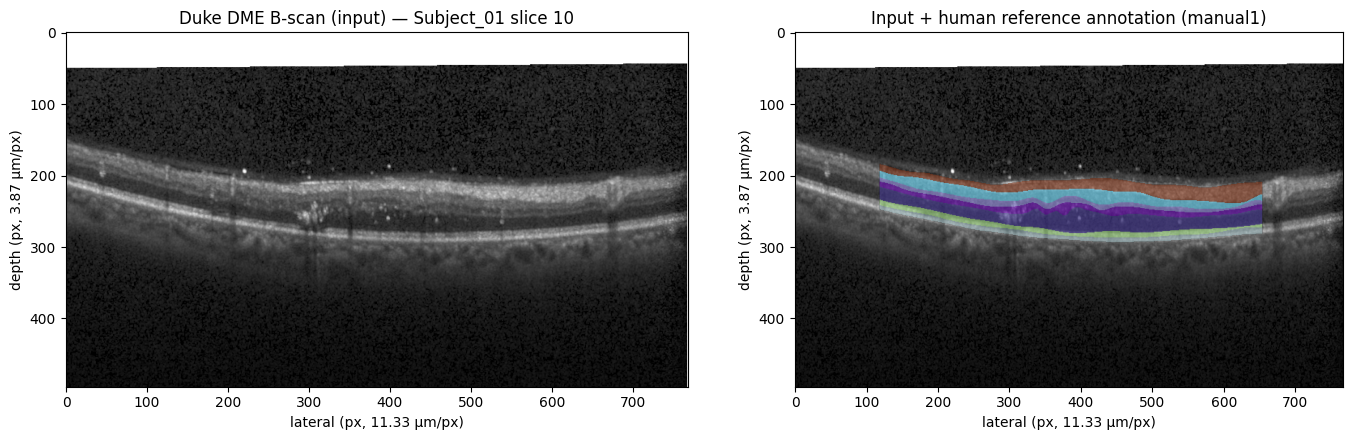

Saved: /content/sample_with_reference.png


In [ ]:
import matplotlib.pyplot as plt

# Author palette (oct_tools/layer_information.py, LAYER_COLORS), label IDs 1-7.
HEX = {1: "#782506", 2: "#5bd5f8", 3: "#9289e8", 4: "#6c02c1",
       5: "#473a9f", 6: "#abec8a", 7: "#8fadb2", 8: "#9e9e9e"}
def colorize(label):
    out = np.zeros(label.shape + (4,))
    for k, hx in HEX.items():
        r, g, b = (int(hx[i:i+2], 16) / 255 for i in (1, 3, 5))
        out[label == k] = (r, g, b, 0.55)
    return out

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].imshow(image2d, cmap="gray", aspect="auto")
axes[0].set_title(f"Duke DME B-scan (input) — {pathlib.Path(MAT_PATH).stem} slice {b_idx}")
axes[1].imshow(image2d, cmap="gray", aspect="auto")
axes[1].imshow(colorize(ref_label))
axes[1].set_title("Input + human reference annotation (manual1)")
for ax in axes:
    ax.set_xlabel("lateral (px, 11.33 µm/px)"); ax.set_ylabel("depth (px, 3.87 µm/px)")
plt.tight_layout(); plt.savefig("/content/sample_with_reference.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: /content/sample_with_reference.png")

## 6. Convert to nnU-Net input format (author's conversion, cited)

nnU-Net requires NIfTI input carrying the voxel size. Following the author's `_convert_to_nnunet_format` (`oct_tools/apply_nnunet.py`) and `prepare_duke_dme(pixel_spacing=(3.87, 11.33))`, we write the uint8 B-scan as a 2D NIfTI with the first array axis (depth rows) scaled by the **axial 3.87 µm** spacing and the second (lateral) by **11.33 µm**, with the `_0000` channel suffix.
**日本語:** 著者のコードに従い、Bスキャンをボクセルサイズ付きNIfTIに変換します。

In [ ]:
import nibabel as nib

affine = np.eye(4)
affine[0, 0] = 3.87   # axial µm/px, first array axis (depth rows)
affine[1, 1] = 11.33  # lateral µm/px, second array axis

IN_DIR = "/content/nnunet_in"; OUT_DIR = "/content/nnunet_out"
os.makedirs(IN_DIR, exist_ok=True); os.makedirs(OUT_DIR, exist_ok=True)
case = "duke_dme_sample"
nib.save(nib.Nifti1Image(image2d.astype(np.uint8), affine), f"{IN_DIR}/{case}_0000.nii.gz")
print("Wrote", f"{IN_DIR}/{case}_0000.nii.gz", image2d.shape)

Wrote /content/nnunet_in/duke_dme_sample_0000.nii.gz (496, 768)


## 7. Run the author-documented inference

Run `nnUNetv2_predict` exactly as in `doc/nnunet.md` (dataset `001`, configuration `2d`, fold `0`, trainer `nnUNetTrainer`), with `-device` set from the environment check above. A single 2D B-scan takes well under a minute on CPU.
**日本語:** 論文のドキュメントどおり `nnUNetv2_predict`（dataset 001, 2d, fold 0）で推論します。デバイスは環境に応じて自動選択されます。

In [ ]:
cmd = ["nnUNetv2_predict", "-i", IN_DIR, "-o", OUT_DIR, "-d", "001", "-c", "2d",
       "-f", "0", "-tr", "nnUNetTrainer", "-device", DEVICE]
print("Running:", " ".join(cmd))
proc = subprocess.run(cmd, env=os.environ, capture_output=True, text=True)
print(proc.stdout[-3000:])
if proc.returncode != 0:
    print(proc.stderr[-3000:])
proc.check_returncode()
assert glob.glob(f"{OUT_DIR}/{case}.nii.gz"), "nnUNetv2_predict produced no segmentation (empty input?)"
print("Segmentation written:", sorted(os.path.basename(p) for p in glob.glob(f"{OUT_DIR}/*.nii.gz")))

Running: nnUNetv2_predict -i /content/nnunet_in -o /content/nnunet_out -d 001 -c 2d -f 0 -tr nnUNetTrainer -device cpu



#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

perform_everything_on_device=True is only supported for cuda devices! Setting this to False
There are 1 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 1 cases that I would like to predict

Predicting duke_dme_sample:
perform_everything_on_device: False
sending off prediction to background worker for resampling and export
done with duke_dme_sample
GPU prediction completed. Waiting for remaining segmentation exports to finish...
Segmentation export complete.

Segmentation written: ['duke_dme_sample.nii.gz']


Load the predicted segmentation and report the layer IDs present. The model's labels are 1–7 (RNFL, GCIPL, INL, OPL, ONL, EZ, RPE — `oct_tools/layer_information.py`), verified against the installed `dataset.json` above.
**日本語:** 予測セグメンテーションを読み込み、含まれる層IDを確認します。

In [ ]:
seg = np.asanyarray(nib.load(f"{OUT_DIR}/{case}.nii.gz").dataobj).astype(np.uint8)
print("Prediction shape:", seg.shape, "| label IDs:", np.unique(seg).tolist())
if seg.shape != image2d.shape:
    print("WARNING: prediction shape differs from input; resampling was applied by nnU-Net.")

LABEL_NAMES = {1: "RNFL", 2: "GCIPL", 3: "INL", 4: "OPL", 5: "ONL", 6: "EZ", 7: "RPE"}

Prediction shape: (496, 768) | label IDs: [0, 1, 2, 3, 4, 5, 6, 7]


### Result: model prediction on the input

Display the input with the **model prediction** overlay (author's 7-layer palette). This overlay is the reproduction result of this run; the human reference overlay above is shown separately so the two are never confused.
**日本語:** モデル予測のオーバーレイ。上の人手アノテーションとは別の図として示します。

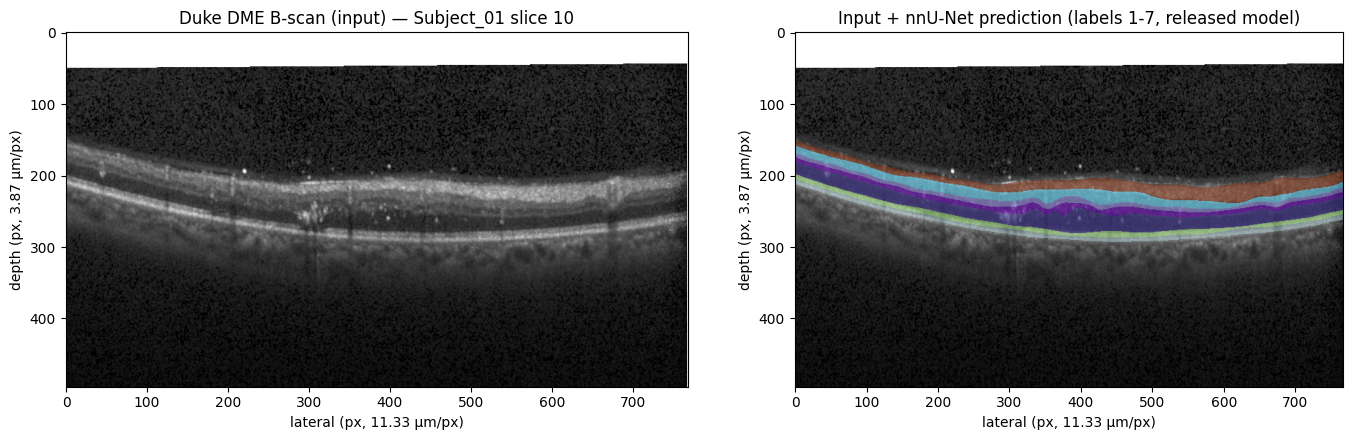

Saved: /content/sample_with_prediction.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].imshow(image2d, cmap="gray", aspect="auto")
axes[0].set_title(f"Duke DME B-scan (input) — {pathlib.Path(MAT_PATH).stem} slice {b_idx}")
axes[1].imshow(image2d, cmap="gray", aspect="auto")
axes[1].imshow(colorize(seg))
axes[1].set_title("Input + nnU-Net prediction (labels 1-7, released model)")
for ax in axes:
    ax.set_xlabel("lateral (px, 11.33 µm/px)"); ax.set_ylabel("depth (px, 3.87 µm/px)")
plt.tight_layout(); plt.savefig("/content/sample_with_prediction.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: /content/sample_with_prediction.png")

## 8. Retinal layer thickness measurement (author's metric, cited)

The paper's core measurement is **layer thickness** (e.g. RNFL, GCIPL) and the **central foveal thickness (CFT)** — the span from the upper RNFL boundary to the lower RPE boundary. We reproduce the author's headless metric from `oct_tools/metric_utils.py`: a layer's thickness per column = (number of label pixels in that column) × axial spacing, and the span = (bottom-most − top-most labeled row + 1) × axial spacing (functions `_compute_thickness_per_column`, `_span_at_reference`). We compare model vs. human annotation per layer (mean thickness over annotated columns and mean absolute difference) and compute the total-retina span at the central column.
**日本語:** 著者の指標（列ごとの層ラベル数 × 軸方向ピクセルサイズ）で層厚を計算し、モデルと人手アノテーションを比較します。

In [ ]:
import pandas as pd

AXIAL_UM = 3.87  # µm/px, Duke DME axial spacing (author's prepare_duke_dme)

def thickness_per_column(mask, label):
    # Author's _compute_thickness_per_column, generalized from label 1 to any label id.
    return (mask == label).sum(axis=0) * AXIAL_UM  # µm

def span_at_reference(segmentation, x):
    # Author's _span_at_reference: distance from topmost to bottommost labeled pixel in a column.
    rows = np.flatnonzero(segmentation[:, x])
    return float(rows[-1] - rows[0] + 1) * AXIAL_UM if rows.size else 0.0

rows = []
for label_id, name in LABEL_NAMES.items():
    if label_id not in np.unique(ref_label) or label_id not in np.unique(seg):
        rows.append({"layer": name, "label_id": label_id, "present": False}); continue
    t_m = thickness_per_column(seg, label_id)
    t_r = thickness_per_column(ref_label, label_id)
    both = (t_m > 0) & (t_r > 0)
    rows.append({
        "layer": name, "label_id": label_id, "present": True,
        "mean thickness model [µm]": round(float(t_m[both].mean()), 2),
        "mean thickness reference [µm]": round(float(t_r[both].mean()), 2),
        "mean |Δ| [µm]": round(float(np.abs(t_m[both] - t_r[both]).mean()), 2),
    })
table = pd.DataFrame(rows)
display(table)

x_mid = W // 2
print(f"Total-retina span at central column x={x_mid}: "
      f"model {span_at_reference(seg, x_mid):.1f} µm vs reference {span_at_reference(ref_label, x_mid):.1f} µm (author's CFT definition)")

table.to_csv("/content/thickness_comparison.csv", index=False)
print("Saved: /content/thickness_comparison.csv")

,layer,label_id,present,mean thickness model [µm],mean thickness reference [µm],mean |Δ| [µm]
0,RNFL,1,True,57.15,57.14,0.94
1,GCIPL,2,True,48.27,48.10,1.10
2,INL,3,True,24.32,24.54,1.00
3,OPL,4,True,29.57,29.93,1.36
4,ONL,5,True,77.40,77.09,1.22
5,EZ,6,True,25.23,25.57,1.13
6,RPE,7,True,26.69,26.88,0.99


Total-retina span at central column x=384: model 325.1 µm vs reference 325.1 µm (author's CFT definition)
Saved: /content/thickness_comparison.csv


### Layer thickness profiles

Layer thickness along the B-scan (model vs. human reference) for the three inner layers the paper focuses on (RNFL, GCIPL, INL). This graph is **created for this notebook** from the single sample above — it is not a figure from the paper and carries no statistical claim.
**日本語:** 内層3層（RNFL, GCIPL, INL）について、モデルと人手アノテーションの層厚プロファイルを比較します。本ノートブック用に作成した追加の可視化であり、論文の図ではありません。

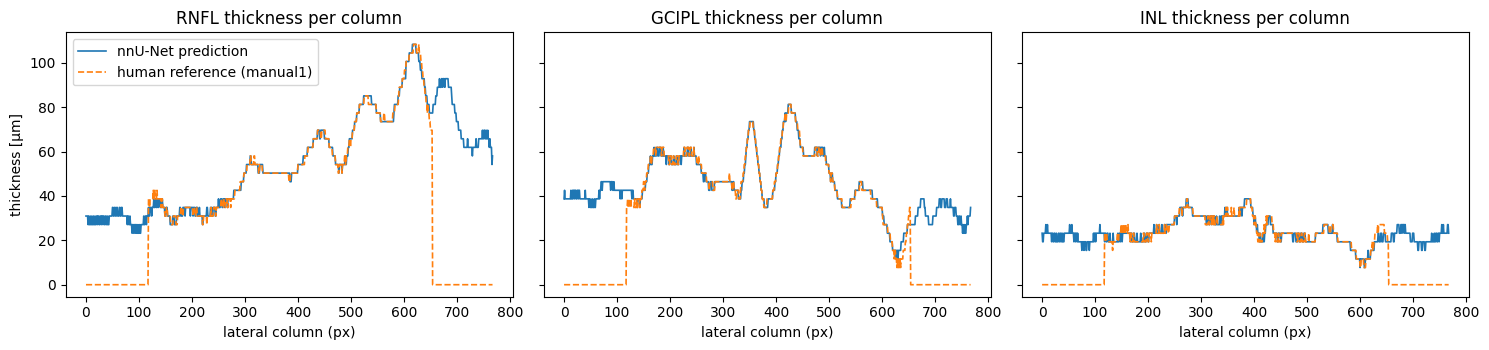

Saved: /content/thickness_profiles.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharey=True)
for ax, name in zip(axes, ["RNFL", "GCIPL", "INL"]):
    lid = next(k for k, v in LABEL_NAMES.items() if v == name)
    ax.plot(thickness_per_column(seg, lid), label="nnU-Net prediction", lw=1.2)
    ax.plot(thickness_per_column(ref_label, lid), label="human reference (manual1)", lw=1.2, ls="--")
    ax.set_title(f"{name} thickness per column"); ax.set_xlabel("lateral column (px)")
axes[0].set_ylabel("thickness [µm]"); axes[0].legend()
plt.tight_layout(); plt.savefig("/content/thickness_profiles.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: /content/thickness_profiles.png")

## 9. Interpretation and limitations

**What this run demonstrates:** the paper's released pretrained nnU-Net segments the 7 retinal layers on a real public OCT B-scan, invoked exactly through the author-documented CLI, and the author's thickness metric produces layer-thickness values and the total-retina (CFT-style) span directly from the segmentation.

**What it does not demonstrate:**
- The paper's headline RP results (nnU-Net precision/recall/F1 ≈ 0.96 on the 20-scan UMG-RP test set) require the **private UMG-RP dataset**, which the authors have not published (README: "Currently (2026-04-29), it is not clear if the data will be published").
- The Duke DME sample here is part of the **model's public training data** — agreement with the `manual1` annotation is a sanity check of the pipeline, not an accuracy claim. Duke `manual1` provides 8 surfaces → 7 bands that map one-to-one onto the model's label IDs; columns without reference annotation are excluded from the per-layer comparison.
- The paper's interactive OCT-SAM workflow (µSAM prompts, napari GUI, ETDRS-like areas) is out of scope of this minimal headless demonstration.
- The author repository has **no LICENSE file**; no author code is redistributed here — the metric logic is re-implemented (cited above) and the author's released artifacts are used through their documented commands.

**日本語:** 本実行は公開済みモデルと公開サンプルによるパイプライン実証です。RP患者データは非公開のため論文の性能値は検証できません。Duke DME は学習データの一部であるため、一致はサニティチェックです。

## References

1. Preprint: DOI [10.64898/2026.06.16.26355668](https://doi.org/10.64898/2026.06.16.26355668) (medRxiv v1, posted June 17, 2026).
2. Author code: [computational-cell-analytics/oct-sam](https://github.com/computational-cell-analytics/oct-sam), commit `012aa0c99cf6d578bb23e94743c13f15f856e7d4` — `doc/nnunet.md`, `oct_tools/apply_nnunet.py`, `oct_tools/metric_utils.py`, `oct_tools/layer_information.py`, `scripts/process_nnunet_data/nnunet_preprocess_external_data.py`.
3. Pretrained nnU-Net model: author ownCloud share `ffZ4MvFWt8E5jpv` (`nnunet_model_001_oct-2d.zip`, 329.3 MB).
4. Duke DME dataset: Chiu et al., BOE 2015 — `https://people.duke.edu/~sf59/Chiu_BOE_2014_dataset.htm`, archive `2015_BOE_Chiu2.zip`; voxel size from the author's data-preparation script.
5. nnU-Net v2: Isensee et al., Nature Methods 2021, [MIC-DKFZ/nnUNet](https://github.com/MIC-DKFZ/nnUNet).